# 📝 Exercise M4.03

Now, we tackle a (relatively) realistic classification problem instead of making
a synthetic dataset. We start by loading the Adult Census dataset with the
following snippet. For the moment we retain only the **numerical features**.

In [1]:
import pandas as pd

adult_census = pd.read_csv("../datasets/adult-census.csv")
target = adult_census["class"]
data = adult_census.select_dtypes(["integer", "floating"])
data = data.drop(columns=["education-num"])
data

,age,capital-gain,capital-loss,hours-per-week
0,25,0,0,40
1,38,0,0,50
2,28,0,0,40
3,44,7688,0,40
4,18,0,0,30
...,...,...,...,...
48837,27,0,0,38
48838,40,0,0,40
48839,58,0,0,40
48840,22,0,0,20


We confirm that all the selected features are numerical.

Define a linear model composed of a `StandardScaler` followed by a
`LogisticRegression` with default parameters.

Then use a 10-fold cross-validation to estimate its generalization performance
in terms of accuracy. Also set `return_estimator=True` to be able to inspect
the trained estimators.

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

cv_results = cross_validate(
    model,
    data,
    target,
    cv=10,
    return_estimator=True
)

print(f"{cv_results['test_score'].mean():.3f}")
estimator = cv_results['estimator']

0.800


In [3]:
cv_1 = cv_results['test_score']

What is the most important feature seen by the logistic regression?

You can use a boxplot to compare the absolute values of the coefficients while
also visualizing the variability induced by the cross-validation resampling.

In [4]:
coefs = pd.DataFrame([model[-1].coef_[0] for model in estimator], columns=data.columns)

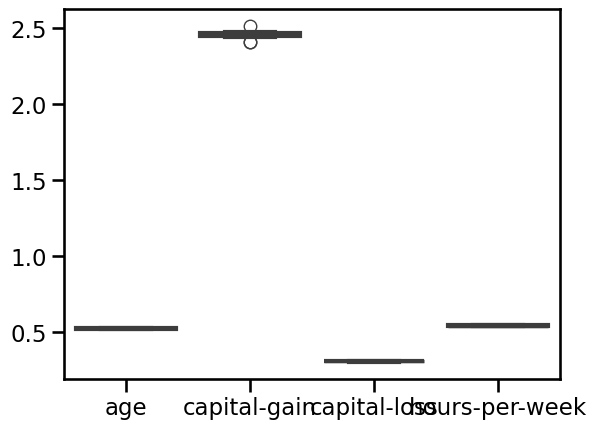

In [5]:
from seaborn import boxplot

_ = boxplot(coefs)

Let's now work with **both numerical and categorical features**. You can
reload the Adult Census dataset with the following snippet:

In [6]:
adult_census = pd.read_csv("../datasets/adult-census.csv")
target = adult_census["class"]
data = adult_census.drop(columns=["class", "education-num"])

Create a predictive model where:
- The numerical data must be scaled.
- The categorical data must be one-hot encoded, set `min_frequency=0.01` to
  group categories concerning less than 1% of the total samples.
- The predictor is a `LogisticRegression` with default parameters, except that
  you may need to increase the number of `max_iter`, which is 100 by default.

Use the same 10-fold cross-validation strategy with `return_estimator=True` as
above to evaluate the full pipeline, including the feature scaling and encoding
preprocessing.

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_selector
from sklearn.compose import make_column_transformer

num_columns = make_column_selector(dtype_exclude=object)(data)
cat_columns = make_column_selector(dtype_include=object)(data)

preprocessor = make_column_transformer(
    (OneHotEncoder(min_frequency=0.01, handle_unknown="ignore"), cat_columns),
    (StandardScaler(), num_columns)
)

model = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=100)    
)

In [8]:
cv_results = cross_validate(
    model,
    data,
    target,
    cv=10,
    return_estimator=True
)

print(f"{cv_results['test_score'].mean():.3f}")
estimator = cv_results['estimator']

0.851


By comparing the cross-validation test scores of both models fold-to-fold,
count the number of times the model using both numerical and categorical
features has a better test score than the model using only numerical features.

In [9]:
cv_2 = cv_results['test_score']

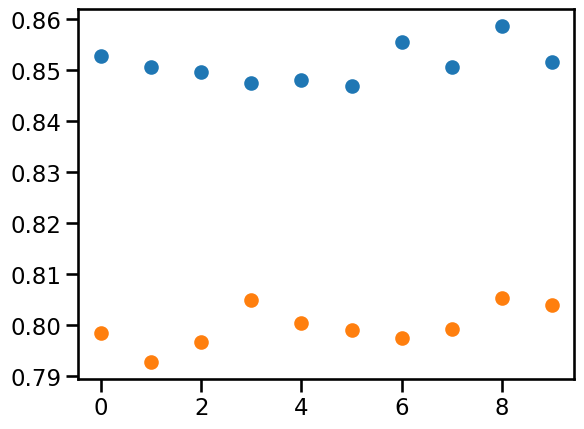

In [12]:
import matplotlib.pyplot as plt
import numpy as np

_ = plt.scatter(np.arange(len(cv_2)), cv_2)
_ = plt.scatter(np.arange(len(cv_1)), cv_1)

### For all folds, using all features is better than only numerical ones.

For the following questions, you can copy and paste the following snippet to
get the feature names from the column transformer here named `preprocessor`.

```python
preprocessor.fit(data)
feature_names = (
    preprocessor.named_transformers_["onehotencoder"].get_feature_names_out(
        categorical_columns
    )
).tolist()
feature_names += numerical_columns
feature_names
```

In [14]:
preprocessor.fit(data)
feature_names = (
    preprocessor.named_transformers_["onehotencoder"].get_feature_names_out(
        cat_columns
    )
).tolist()
feature_names += num_columns
feature_names

['workclass_ ?',
 'workclass_ Federal-gov',
 'workclass_ Local-gov',
 'workclass_ Private',
 'workclass_ Self-emp-inc',
 'workclass_ Self-emp-not-inc',
 'workclass_ State-gov',
 'workclass_infrequent_sklearn',
 'education_ 10th',
 'education_ 11th',
 'education_ 12th',
 'education_ 5th-6th',
 'education_ 7th-8th',
 'education_ 9th',
 'education_ Assoc-acdm',
 'education_ Assoc-voc',
 'education_ Bachelors',
 'education_ Doctorate',
 'education_ HS-grad',
 'education_ Masters',
 'education_ Prof-school',
 'education_ Some-college',
 'education_infrequent_sklearn',
 'marital-status_ Divorced',
 'marital-status_ Married-civ-spouse',
 'marital-status_ Married-spouse-absent',
 'marital-status_ Never-married',
 'marital-status_ Separated',
 'marital-status_ Widowed',
 'marital-status_infrequent_sklearn',
 'occupation_ ?',
 'occupation_ Adm-clerical',
 'occupation_ Craft-repair',
 'occupation_ Exec-managerial',
 'occupation_ Farming-fishing',
 'occupation_ Handlers-cleaners',
 'occupation_ Ma

Notice that there are as many feature names as coefficients in the last step
of your predictive pipeline.

Which of the following pairs of features is most impacting the predictions of
the logistic regression classifier based on the absolute magnitude of its
coefficients?

In [48]:
coefs = [
    pipeline[1].coef_[0] for pipeline in estimator
]

<Axes: >

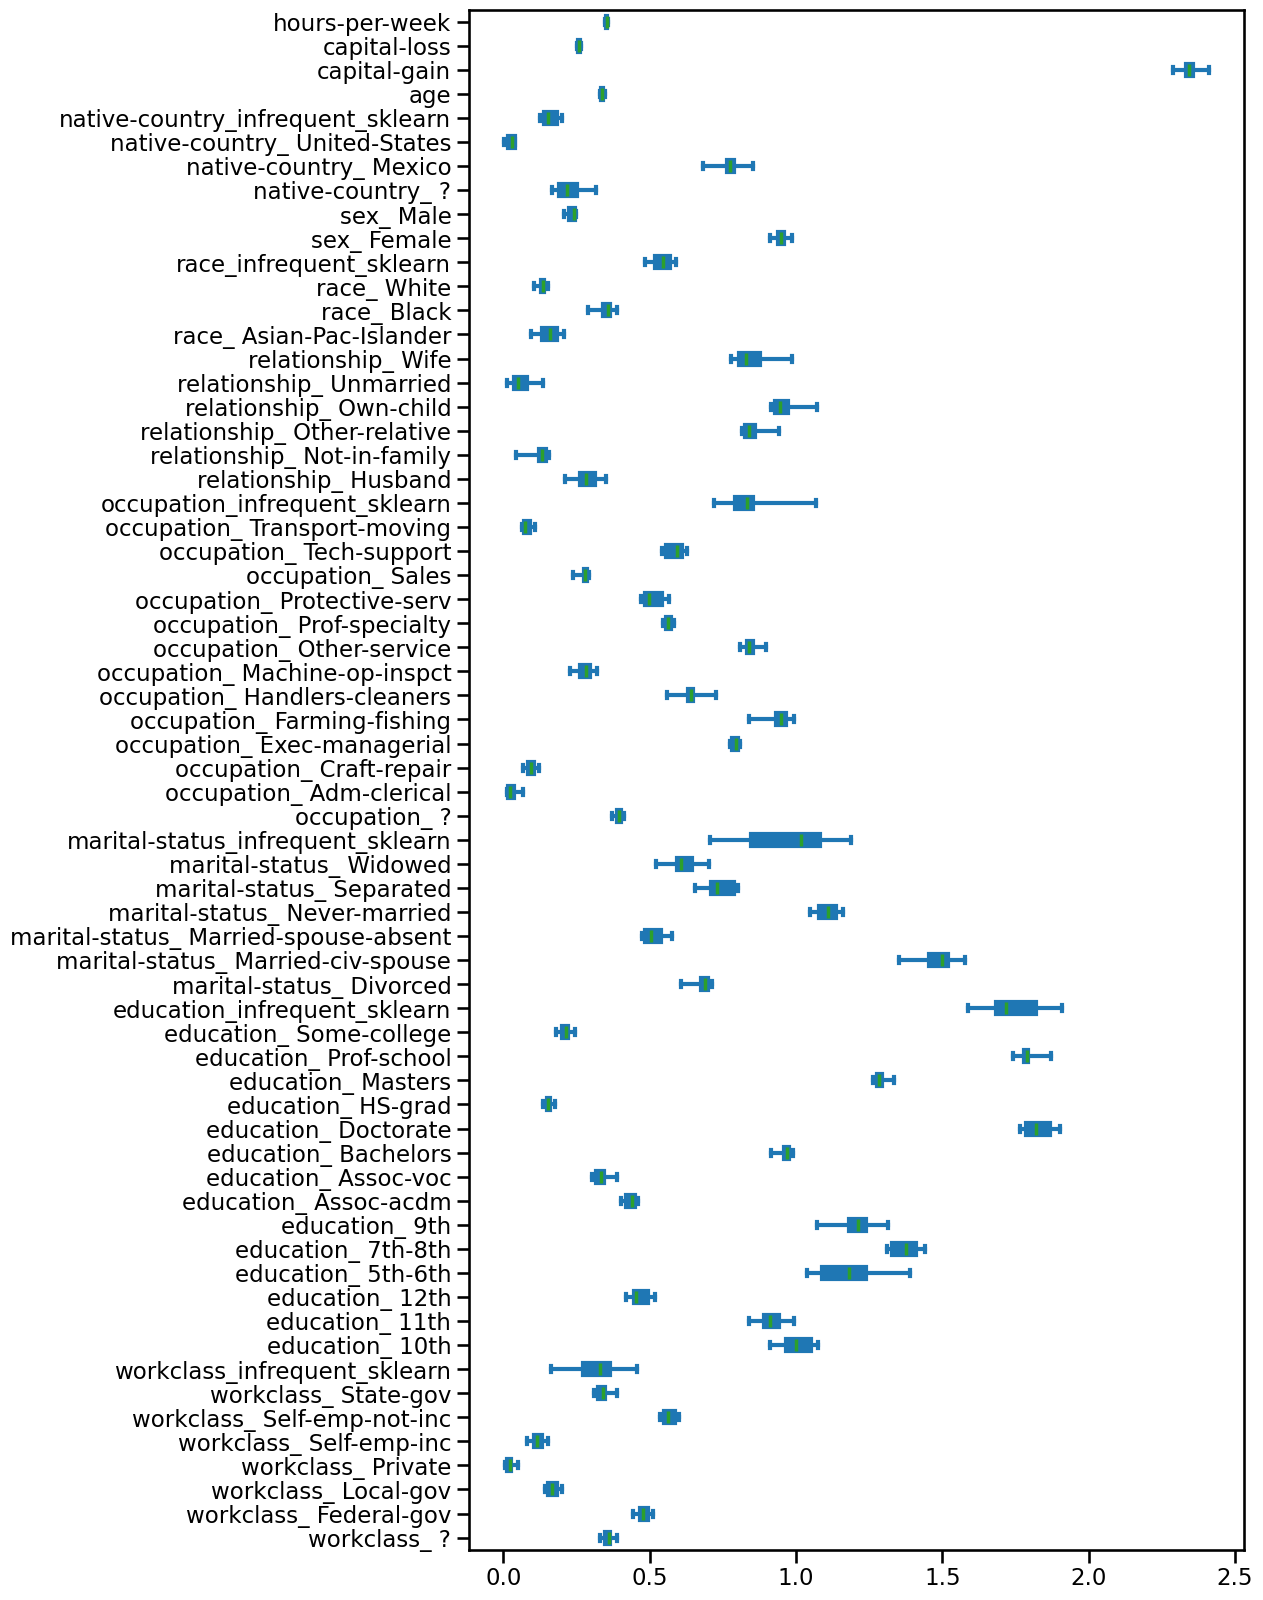

In [49]:
coefs = pd.DataFrame(coefs, columns=feature_names)

_, ax = plt.subplots(figsize=(10,20))
coefs.abs().plot.box(vert=False, ax=ax)

Now create a similar pipeline consisting of the same preprocessor as above,
followed by a `PolynomialFeatures` and a logistic regression with `C=0.01` and
enough `max_iter`. Set `degree=2` and `interaction_only=True` to the feature
engineering step. Remember not to include a "bias" feature to avoid
introducing a redundancy with the intercept of the subsequent logistic
regression.

In [58]:
from sklearn.preprocessing import PolynomialFeatures

pipeline_3 = make_pipeline(
    preprocessor,
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
    LogisticRegression(C=0.01, max_iter=100)
)

Use the same 10-fold cross-validation strategy as above to evaluate this
pipeline with interactions. In this case there is no need to return the
estimator, as the number of features generated by the `PolynomialFeatures` step
is much too large to be able to visually explore the learned coefficients of the
final classifier.

By comparing the cross-validation test scores of both models fold-to-fold,
count the number of times the model using multiplicative interactions and both
numerical and categorical features has a better test score than the model
without interactions.

In [59]:
cv_results_3 = cross_validate(
    pipeline_3,
    data,
    target,
    cv=10
)

In [61]:
cv_results_3['test_score'].mean()

np.float64(0.8527496380720537)

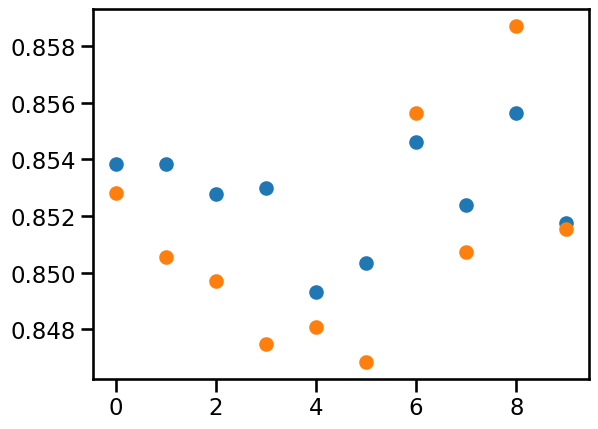

In [66]:
_ = plt.scatter(np.arange(len(cv_results_3['test_score'])), cv_results_3['test_score'])
_ = plt.scatter(np.arange(len(cv_2)), cv_2)

### The last model has better scores 8 out of 10 times.